## Library Import Setup

In [9]:
import importlib.util
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/kcv-if/Modul-Praktikum-KK-RKA-25.git"
ON_COLAB = "google.colab" in sys.modules


def ensure_dependencies():
    """Install only the packages this module actually uses."""
    required = {
        "networkx": "networkx",
        "numpy": "numpy",
        "pandas": "pandas",
        "matplotlib": "matplotlib",
        "ipywidgets": "ipywidgets",
        "PIL": "pillow",
        "pygments": "pygments",
    }
    missing = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]
    if missing:
        print("Installing:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)


def find_environment(start):
    """Locate the folder that holds logic.py and utils.py, searching upward."""
    for root in [start, *start.parents]:
        for candidate in sorted(root.rglob("logic.py")):
            if (candidate.parent / "utils.py").exists():
                return candidate.parent
        if (root / ".git").exists():
            break
    return None


ensure_dependencies()

start_dir = Path.cwd()
if ON_COLAB:
    clone_dir = Path("Modul-Praktikum-KK-RKA-25")
    if not clone_dir.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(clone_dir)], check=True)
    start_dir = clone_dir

ENV_DIR = find_environment(start_dir)
if ENV_DIR is None:
    raise RuntimeError(
        "Environment folder not found. Make sure this notebook is opened from "
        "inside the Modul-Praktikum-KK-RKA-25 repository."
    )
if str(ENV_DIR) not in sys.path:
    sys.path.insert(0, str(ENV_DIR))

import itertools
import warnings

import pandas as pd

# qpsolvers is only used by the SVM code, which this module never touches.
warnings.filterwarnings("ignore", message="no QP solver found")

from logic import *
from notebook import psource
from utils import *

print("Environment :", ENV_DIR)
print("Python      :", sys.version.split()[0])
print("Check       : tt_entails(P & Q, Q) =", tt_entails(expr("P & Q"), expr("Q")))

Environment : /home/ryz/data/collage/sem 3/kk/repo/week2/environment
Python      : 3.10.20
Check       : tt_entails(P & Q, Q) = True


## Function Set Up




In [10]:
import textwrap

import matplotlib.pyplot as plt


def make_kb(facts, rules):
    """Build a PropDefiniteKB from fact and rule strings."""
    kb = PropDefiniteKB()
    for sentence in [*facts, *rules]:
        kb.tell(expr(sentence))
    return kb


def _as_expr(value):
    """Accept either an Expr or a string containing one expression."""
    return expr(value) if isinstance(value, str) else value


def _agenda_text(agenda):
    """Format an agenda with the next item to process on the right."""
    return " → ".join(str(item) for item in agenda) or "(kosong)"


def ask_forward(kb, query):
    """Run forward chaining and return (result, trace_dataframe)."""
    goal = _as_expr(query)
    count = {}
    premise_index = {}

    for clause in kb.clauses:
        if clause.op != "==>":
            continue
        premises = conjuncts(clause.args[0])
        count[clause] = len(premises)
        for premise in premises:
            premise_index.setdefault(premise, []).append(clause)

    initial_facts = [
        clause for clause in kb.clauses if is_prop_symbol(clause.op)
    ]
    agenda = list(dict.fromkeys(initial_facts))
    known = set(agenda)
    inferred = set()
    rows = []

    while agenda:
        agenda_before = list(agenda)
        fact = agenda.pop()
        step = len(rows) + 1

        if fact == goal:
            rows.append({
                "langkah": step,
                "agenda sebelum": _agenda_text(agenda_before),
                "fact diproses": str(fact),
                "rule aktif": "-",
                "conclusion baru": "-",
                "agenda sesudah": _agenda_text(agenda),
                "keputusan": "Query ditemukan; proses berhenti.",
            })
            trace = pd.DataFrame(rows)
            trace.attrs["query"] = str(goal)
            return True, trace

        if fact in inferred:
            continue

        inferred.add(fact)
        fired_rules = []
        new_conclusions = []
        known_conclusions = []

        for clause in premise_index.get(fact, []):
            count[clause] -= 1
            if count[clause] != 0:
                continue

            conclusion = clause.args[1]
            fired_rules.append(str(clause))
            if conclusion in known:
                known_conclusions.append(str(conclusion))
            else:
                known.add(conclusion)
                agenda.append(conclusion)
                new_conclusions.append(str(conclusion))

        if not fired_rules:
            decision = "Belum ada rule baru yang seluruh premise-nya terpenuhi."
        else:
            messages = []
            if new_conclusions:
                messages.append(
                    "Tambahkan " + ", ".join(new_conclusions) + " ke agenda."
                )
            if known_conclusions:
                messages.append(
                    ", ".join(known_conclusions) + " sudah diketahui; tidak ditambahkan ulang."
                )
            decision = " ".join(messages)

        rows.append({
            "langkah": step,
            "agenda sebelum": _agenda_text(agenda_before),
            "fact diproses": str(fact),
            "rule aktif": ", ".join(fired_rules) or "-",
            "conclusion baru": ", ".join(new_conclusions) or "-",
            "agenda sesudah": _agenda_text(agenda),
            "keputusan": decision,
        })

    trace = pd.DataFrame(rows)
    trace.attrs["query"] = str(goal)
    return False, trace


def visualize_forward(trace):
    """Visualize each forward-chaining decision as one horizontal step."""
    if trace.empty:
        print("Trace kosong: tidak ada fact yang dapat diproses.")
        return

    query = trace.attrs.get("query", "?")
    figure_height = max(2.4, 2.25 * len(trace))
    figure, axes = plt.subplots(
        len(trace), 1, figsize=(14, figure_height), squeeze=False
    )

    for axis, (_, row) in zip(axes[:, 0], trace.iterrows()):
        axis.set_xlim(0, 1)
        axis.set_ylim(0, 1)
        axis.axis("off")

        query_found = "Query ditemukan" in row["keputusan"]
        decision_color = "#d1fae5" if query_found else "#e0f2fe"

        axis.text(
            0.01, 0.72, f"Langkah {row['langkah']}",
            fontsize=12, fontweight="bold", va="center"
        )
        axis.text(
            0.14, 0.72,
            "Agenda sebelum\n" + textwrap.fill(row["agenda sebelum"], 22),
            fontsize=10, va="center", ha="center",
            bbox={"boxstyle": "round,pad=0.5", "facecolor": "#f3f4f6", "edgecolor": "#6b7280"},
        )
        axis.annotate("", xy=(0.38, 0.72), xytext=(0.31, 0.72),
                      arrowprops={"arrowstyle": "->", "color": "#374151", "lw": 1.5})
        axis.text(
            0.43, 0.72, f"Proses fact\n{row['fact diproses']}",
            fontsize=10, va="center", ha="center",
            bbox={"boxstyle": "round,pad=0.5", "facecolor": "#fef3c7", "edgecolor": "#d97706"},
        )
        axis.annotate("", xy=(0.59, 0.72), xytext=(0.50, 0.72),
                      arrowprops={"arrowstyle": "->", "color": "#374151", "lw": 1.5})

        decision_text = (
            "Rule aktif: " + textwrap.fill(row["rule aktif"], 42)
            + "\nConclusion baru: " + row["conclusion baru"]
            + "\n" + textwrap.fill(row["keputusan"], 52)
        )
        axis.text(
            0.78, 0.72, decision_text,
            fontsize=9.5, va="center", ha="center",
            bbox={"boxstyle": "round,pad=0.55", "facecolor": decision_color, "edgecolor": "#0284c7"},
        )
        axis.text(
            0.14, 0.16,
            "Agenda sesudah: " + textwrap.fill(row["agenda sesudah"], 75),
            fontsize=9.5, va="center", ha="left",
        )
        axis.plot([0.01, 0.99], [0.02, 0.02], color="#d1d5db", linewidth=1)

    figure.suptitle(
        f"Visualisasi Forward Chaining — Query: {query}",
        fontsize=15, fontweight="bold", y=1.005,
    )
    figure.text(
        0.5, 0.002,
        "Agenda dibaca dari kiri ke kanan; item paling kanan diproses berikutnya.",
        ha="center", fontsize=9, color="#4b5563",
    )
    plt.tight_layout()
    plt.show()


def ask_backward(kb, query):
    """Run backward chaining and return (result, trace_dataframe)."""
    goal = _as_expr(query)
    facts = {clause for clause in kb.clauses if is_prop_symbol(clause.op)}
    rules_by_conclusion = {}

    for clause in kb.clauses:
        if clause.op == "==>":
            premises, conclusion = parse_definite_clause(clause)
            rules_by_conclusion.setdefault(conclusion, []).append(
                (clause, premises)
            )

    rows = []

    def prove(current_goal, goals_in_branch, depth, parent_step):
        step = len(rows) + 1
        row_index = len(rows)
        rows.append({
            "langkah": step,
            "parent": parent_step if parent_step is not None else "-",
            "depth": depth,
            "goal": str(current_goal),
            "rule diperiksa": "-",
            "rule berhasil": "-",
            "keputusan": "Periksa goal.",
            "hasil": None,
        })

        if current_goal in facts:
            rows[row_index]["keputusan"] = "Goal sudah tersedia sebagai fact."
            rows[row_index]["hasil"] = True
            return True

        if current_goal in goals_in_branch:
            rows[row_index]["keputusan"] = (
                "Goal yang sama sudah diperiksa pada branch ini; branch dihentikan."
            )
            rows[row_index]["hasil"] = False
            return False

        supporting_rules = rules_by_conclusion.get(current_goal, [])
        if not supporting_rules:
            rows[row_index]["keputusan"] = (
                "Tidak ada fact atau rule yang menghasilkan goal."
            )
            rows[row_index]["hasil"] = False
            return False

        next_branch = goals_in_branch | {current_goal}
        tried_rules = []

        for clause, premises in supporting_rules:
            tried_rules.append(str(clause))
            premise_results = []
            for premise in premises:
                premise_result = prove(premise, next_branch, depth + 1, step)
                premise_results.append(premise_result)
                if not premise_result:
                    break

            if all(premise_results):
                rows[row_index]["rule diperiksa"] = " | ".join(tried_rules)
                rows[row_index]["rule berhasil"] = str(clause)
                rows[row_index]["keputusan"] = (
                    "Semua premise pada rule berhasil dibuktikan."
                )
                rows[row_index]["hasil"] = True
                return True

        rows[row_index]["rule diperiksa"] = " | ".join(tried_rules)
        rows[row_index]["keputusan"] = "Semua rule pendukung gagal."
        rows[row_index]["hasil"] = False
        return False

    found = prove(goal, set(), depth=0, parent_step=None)
    trace = pd.DataFrame(rows)
    trace.attrs["query"] = str(goal)
    return found, trace


def visualize_backward(trace):
    """Visualize a backward-chaining trace as a proof-search tree."""
    if trace.empty:
        print("Trace kosong: tidak ada goal yang diperiksa.")
        return

    query = trace.attrs.get("query", "?")
    max_depth = int(trace["depth"].max())
    node_count = len(trace)
    x_spacing = 2.7
    positions = {
        int(row["langkah"]): (float(row["depth"]) * x_spacing, -int(row["langkah"]))
        for _, row in trace.iterrows()
    }

    figure_width = max(12, 5 + (max_depth + 1) * 2.35)
    figure_height = max(5, 1.25 * node_count)
    figure, axis = plt.subplots(figsize=(figure_width, figure_height))

    for _, row in trace.iterrows():
        step = int(row["langkah"])
        parent = row["parent"]
        if parent == "-":
            continue
        parent_step = int(parent)
        parent_x, parent_y = positions[parent_step]
        child_x, child_y = positions[step]
        axis.annotate(
            "",
            xy=(child_x, child_y + 0.28),
            xytext=(parent_x, parent_y - 0.28),
            arrowprops={"arrowstyle": "->", "color": "#64748b", "lw": 1.4},
        )

    for _, row in trace.iterrows():
        step = int(row["langkah"])
        x, y = positions[step]
        decision = str(row["keputusan"])
        result = bool(row["hasil"])

        if result:
            facecolor, edgecolor = "#d1fae5", "#059669"
        else:
            facecolor, edgecolor = "#fee2e2", "#dc2626"

        successful_rule = str(row["rule berhasil"])
        rule_line = (
            "\nRule: " + textwrap.fill(successful_rule, 34)
            if successful_rule != "-"
            else ""
        )
        label = (
            f"Langkah {step} | Goal: {row['goal']}"
            f"\nHasil: {result}"
            f"{rule_line}"
            f"\n{textwrap.fill(decision, 38)}"
        )
        axis.text(
            x, y, label,
            ha="center", va="center", fontsize=9.2,
            bbox={
                "boxstyle": "round,pad=0.55",
                "facecolor": facecolor,
                "edgecolor": edgecolor,
                "linewidth": 1.4,
            },
        )

    axis.set_xlim(-1.8, max(1.8, max_depth * x_spacing + 1.8))
    axis.set_ylim(-node_count - 1, 0)
    axis.axis("off")
    axis.set_title(
        f"Visualisasi Backward Chaining — Query: {query}",
        fontsize=15, fontweight="bold", pad=20,
    )
    figure.text(
        0.5, 0.005,
        "Hijau = goal berhasil dibuktikan, merah = goal gagal dibuktikan.",
        ha="center", fontsize=9, color="#4b5563",
    )
    plt.tight_layout()
    plt.show()


---
# Bagian A — Latihan Propositional Logic (Notebook 03)


---
# Latihan Soal

## Soal 1: Diskusi Kelompok

**Slide 27**

> Diketahui proposisi atomic $x_1$, $x_2$, $x_3$ di mana $x_i$ merupakan notasi
> untuk kalimat "pegawai i sedang bekerja". Buatlah proposisi sesuai kondisi
> berikut:
>
> 1. Salah satu dari pegawai 1, 2 dan 3 sedang bekerja.
> 2. Terdapat dua pegawai dari pegawai 1, 2, dan 3 yang sedang bekerja.
> 3. Tidak semua pegawai sedang bekerja.
>
> Jika sudah, diskusikan jawaban kelompokmu dengan kelompok lain.

Terjemahkan tiap kondisi jadi proposisi, lalu cek jawabanmu dengan fungsi
`satisfying_models` di bawah, yang mengembalikan semua model (dari 8 model
yang mungkin) yang membuat proposisimu bernilai benar. Simbolnya ditulis
`X1`, `X2`, `X3` (uppercase) di kode, mewakili $x_1$, $x_2$, $x_3$ di soal.
`pl_true` cuma mengenali simbol yang diawali huruf besar sebagai proposition
symbol.

In [11]:
def satisfying_models(sentence, syms):
    """Enumerate every model over `syms` and return the ones where `sentence` is true."""
    models = []
    for values in itertools.product([False, True], repeat=len(syms)):
        model = dict(zip(syms, values))
        if pl_true(sentence, model):
            models.append(model)
    return models


X1, X2, X3 = expr('X1, X2, X3')
print("Total kemungkinan model:", 2 ** 3)

Total kemungkinan model: 8


In [12]:
# Soal 1.1: "Salah satu dari pegawai 1,2,3 bekerja"
# X1, X2, X3 sudah didefinisikan di sel satisfying_models di atas.
at_least_one = X1 | X2 | X3
exactly_one = (X1 & ~X2 & ~X3) | (~X1 & X2 & ~X3) | (~X1 & ~X2 & X3)

print("1a paling sedikit satu:", len(satisfying_models(at_least_one, [X1, X2, X3])), "model")
print("1b tepat satu         :", len(satisfying_models(exactly_one, [X1, X2, X3])), "model")

# Soal 1.2: "Terdapat dua pegawai bekerja"
at_least_two = (X1 & X2) | (X1 & X3) | (X2 & X3)
exactly_two = (X1 & X2 & ~X3) | (X1 & ~X2 & X3) | (~X1 & X2 & X3)

print("2a paling sedikit dua:", len(satisfying_models(at_least_two, [X1, X2, X3])), "model")
print("2b tepat dua         :", len(satisfying_models(exactly_two, [X1, X2, X3])), "model")

# Soal 1.3: "Tidak semua bekerja" 
not_all = ~(X1 & X2 & X3)
none = ~X1 & ~X2 & ~X3

print("3a tidak semua (benar):", len(satisfying_models(not_all, [X1, X2, X3])), "model")
print("3b tidak ada (keliru) :", len(satisfying_models(none, [X1, X2, X3])), "model")

1a paling sedikit satu: 7 model
1b tepat satu         : 3 model
2a paling sedikit dua: 4 model
2b tepat dua         : 3 model
3a tidak semua (benar): 7 model
3b tidak ada (keliru) : 1 model


<details>
<summary>Klik untuk melihat hint</summary>

Nomor 1 dan 2 sengaja ambigu -- itu bagian dari pelajarannya, jangan
diselesaikan sepihak. Coba tulis **dua** versi proposisi untuk masing-masing
("paling sedikit satu/dua" lawan "tepat satu/dua"), lalu bandingkan
`len(satisfying_models(...))` dari kedua versi itu -- beda tidak?

Nomor 3, hati-hati: "tidak semua bekerja" tidak sama dengan "tidak ada yang
bekerja". Tulis dulu $\neg(x_1 \land x_2 \land x_3)$ apa adanya (jangan buru-
buru disederhanakan), lalu bandingkan jumlah model yang memenuhinya dengan
jumlah model untuk $\neg x_1 \land \neg x_2 \land \neg x_3$.

</details>

## Soal 2

Buktikan hukum De Morgan $\neg(P \land Q) \equiv \neg P \lor \neg Q$ dengan
truth table yang dibangkitkan pakai `pl_true` untuk semua kombinasi $P$ dan
$Q$, bukan dihitung manual.

In [13]:
P, Q = expr('P, Q')
lhs = ~(P & Q)
rhs = ~P | ~Q
equiv = expr('~(P & Q) <=> (~P | ~Q)')

rows_dm = []
for p_val, q_val in itertools.product([False, True], repeat=2):
    model = {P: p_val, Q: q_val}
    l, r = pl_true(lhs, model), pl_true(rhs, model)
    rows_dm.append({"P": p_val, "Q": q_val, "~(P&Q)": l, "~P|~Q": r, "sama?": l == r})

table_dm = pd.DataFrame(rows_dm)
print(table_dm.to_string(index=False))
print("Semua baris sama?", bool(all(table_dm["sama?"])))

    P     Q  ~(P&Q)  ~P|~Q  sama?
False False    True   True   True
False  True    True   True   True
 True False    True   True   True
 True  True   False  False   True
Semua baris sama? True


<details>
<summary>Klik untuk melihat hint</summary>

Bangun `lhs` dan `rhs` sebagai `Expr` sesuai kedua sisi persamaannya, lalu
loop `itertools.product` untuk $P$, $Q$ persis pola yang sama dengan tabel
di 3.4 -- bandingkan `pl_true` keduanya di tiap baris, jangan dihitung
manual dulu. Kalau di semua baris nilainya sama, apa artinya itu buat
kalimat $\text{lhs} \Leftrightarrow \text{rhs}$ (lihat "Vocabulary
tambahan" di 3.4)?

</details>

## Soal 3

Di 3.2 disebutkan implikasi ($\Rightarrow$) adalah konektif yang jadi bentuk
*rule* KB nanti di Notebook 04, misalnya kalimat seperti "kalau ada breeze di
suatu kotak, maka ada pit di salah satu kotak tetangganya." Implikasi
material tidak mensyaratkan premise dan conclusion saling berhubungan makna
(3.4): implikasi otomatis bernilai benar begitu premise-nya salah, berapa
pun nilai conclusion-nya.

Jelaskan dengan kata-katamu sendiri: kenapa sifat ini justru yang membuat
implikasi material cocok dipakai sebagai bentuk rule KB Wumpus World, bukan
gangguan yang perlu dihindari? Bayangkan agent memakai rule "kalau breeze di
$[x,y]$, maka pit di salah satu tetangganya" — apa yang salah dengan KB
seorang agent kalau rule itu justru dianggap **salah** (bukan otomatis
benar) setiap kali agent tidak merasakan breeze di $[x,y]$?

Jawaban tidak cukup satu baris: kaitkan dengan tabel implikasi di 3.4, dan
pakai alasan yang spesifik ke skenario Wumpus, bukan cuma definisi umum
implikasi material.

## Jawab

Pada Tabel 3.4, implikasi $P \Rightarrow Q$ hanya bernilai salah pada satu kondisi, yaitu ketika $P$ bernilai benar tetapi $Q$ bernilai salah. Pada dua kondisi lainnya saat $P$ bernilai salah, implikasi tetap dianggap benar. Hal ini bukan kesalahan dalam logika, melainkan memang dirancang agar aturan bersyarat hanya dilanggar ketika syaratnya terpenuhi.

Sebagai contoh, perhatikan aturan dalam Wumpus World:

> Jika terdapat *breeze* pada kotak $[x,y]$, maka terdapat *pit* pada salah satu kotak tetangganya.

Aturan ini seharusnya hanya dianggap salah jika agent benar-benar merasakan *breeze*, tetapi ternyata tidak ada *pit* di tetangga mana pun. Sebaliknya, ketika agent tidak merasakan *breeze*, aturan tersebut tidak memberikan informasi apa pun tentang keberadaan *pit*. Dalam kondisi ini, aturan dianggap tetap benar karena tidak ada pelanggaran terhadap syarat yang diberikan.

Definisi ini sangat penting dalam sistem berbasis pengetahuan (*Knowledge Base* atau **KB**). Jika implikasi didefinisikan berbeda, misalnya dianggap salah setiap kali premis $P$ bernilai salah, maka setiap kotak yang aman dan tidak memiliki *breeze* justru akan membuat aturan pada kotak tersebut bernilai salah. Karena KB dibangun sebagai konjungsi dari seluruh aturan,

$$
KB = R_1 \land R_2 \land \cdots \land R_n,
$$

satu aturan yang salah saja sudah cukup membuat keseluruhan KB menjadi salah. Akibatnya, tidak akan ada model yang memenuhi KB,

$$
M(KB)=\varnothing.
$$

Situasi tersebut menimbulkan masalah yang lebih serius. Dalam logika, jika tidak ada model yang memenuhi KB, maka hubungan *entailment*

$$
M(KB) \subseteq M(\alpha)
$$

akan selalu dianggap benar untuk proposisi apa pun. Dengan kata lain, agent dapat "membuktikan" sembarang kesimpulan, bahkan kesimpulan yang tidak masuk akal. Fenomena ini dikenal sebagai **principle of explosion** (*ex falso quodlibet*), yaitu ketika basis pengetahuan yang tidak memiliki model membuat setiap proposisi menjadi konsekuensi logisnya.

Oleh karena itu, konsep **vacuous truth** pada implikasi diperlukan agar aturan hanya aktif ketika premisnya benar dan tidak merusak konsistensi keseluruhan *Knowledge Base*.

In [14]:
Bxy, Ptet = expr('Bxy, Ptet')
rule = expr('Bxy ==> Ptet')

print("Implikasi material Bxy ==> Ptet:")
for b, p in itertools.product([False, True], repeat=2):
    print(f"  breeze={str(b):5} pit-tetangga={str(p):5} -> {pl_true(rule, {Bxy: b, Ptet: p})}")

# Definisi "rusak": false setiap premis false (totalnya == Bxy & Ptet).
def fake_implies(p, q):
    return p and q

print("Definisi rusak (false saat premis false):")
for b, p in itertools.product([False, True], repeat=2):
    print(f"  breeze={str(b):5} pit-tetangga={str(p):5} -> {fake_implies(b, p)}")

# KB dua kotak: kotak A tanpa breeze, kotak B dengan breeze + pit tetangga.
kb_material = pl_true(rule, {Bxy: False, Ptet: False}) and pl_true(rule, {Bxy: True, Ptet: True})
kb_rusak = fake_implies(False, False) and fake_implies(True, True)
print("KB material (satu kotak aman):", kb_material)
print("KB rusak (satu kotak aman)   :", kb_rusak, "-> M(KB) kosong, entailment vacuous")

Implikasi material Bxy ==> Ptet:
  breeze=False pit-tetangga=False -> True
  breeze=False pit-tetangga=True  -> True
  breeze=True  pit-tetangga=False -> False
  breeze=True  pit-tetangga=True  -> True
Definisi rusak (false saat premis false):
  breeze=False pit-tetangga=False -> False
  breeze=False pit-tetangga=True  -> False
  breeze=True  pit-tetangga=False -> False
  breeze=True  pit-tetangga=True  -> True
KB material (satu kotak aman): True
KB rusak (satu kotak aman)   : False -> M(KB) kosong, entailment vacuous


<details>
<summary>Klik untuk melihat hint</summary>

Bayangkan implikasi didefinisikan ulang supaya bernilai **false** ketika
premise-nya false (kebalikan dari sekarang). KB adalah conjunction dari
semua rule yang di-tell ke dalamnya (Notebook 02). Kalau ada **satu saja**
kotak tanpa breeze, apa yang terjadi pada rule breeze-pit untuk kotak itu
di bawah definisi baru ini -- dan lewat operator AND, apa yang terjadi ke
**seluruh** KB?

Cek juga definisi entailment dari Notebook 02, $M(KB) \subseteq
M(\alpha)$: apa yang terjadi pada definisi itu kalau $M(KB)$ ternyata
kosong di setiap model?

</details>

---
# Bagian B — Latihan Forward & Backward Chaining (Notebook 04)


---
# Latihan Soal

Gunakan satu kasus yang sama untuk Soal 1-3. Tujuannya agar terlihat bahwa
forward chaining dan backward chaining dapat memakai KB Horn clause yang sama,
tetapi memulai pembuktian dari arah yang berbeda.

## Soal 1 — Membuat KB Horn Clause

Diketahui informasi berikut:

1. `A`, `B`, dan `C` adalah fact;
2. jika `A` dan `B` benar, maka `D` benar;
3. jika `B` dan `C` benar, maka `E` benar;
4. jika `D` dan `E` benar, maka `F` benar;
5. jika `F` benar, maka `G` benar.

Buat KB dengan panduan berikut:

1. tulis fact sebagai list string bernama `exercise_facts`;
2. ubah setiap kalimat "jika ... maka ..." menjadi rule dengan simbol `==>`;
3. gunakan `&` jika sebuah rule mempunyai lebih dari satu premise;
4. pastikan setiap rule mempunyai tepat satu conclusion;
5. buat `exercise_kb` dengan `make_kb(exercise_facts, exercise_rules)`;
6. tampilkan `exercise_kb.clauses` dan periksa apakah seluruh fact dan rule sudah
   masuk ke KB.

Tuliskan juga premise dan conclusion dari setiap rule yang dibuat.


In [15]:
exercise_facts = ["A", "B", "C"]

exercise_rules = [
    "(A & B) ==> D",
    "(B & C) ==> E",
    "(D & E) ==> F",
    "F ==> G",
]

exercise_kb = make_kb(exercise_facts, exercise_rules)

print("Fact:")
for fact in exercise_facts:
    print("-", fact)

print("\nRule:")
for rule in exercise_rules:
    print("-", rule)

print("\nJumlah klausa dalam KB:", len(exercise_kb.clauses))
print("\nIsi exercise_kb.clauses:")
for clause in exercise_kb.clauses:
    print("-", clause)

print("\nPremise dan conclusion tiap rule:")
for rule in exercise_rules:
    premises, conclusion = parse_definite_clause(expr(rule))
    print(f"- {rule} | premise={list(premises)} | conclusion={conclusion}")

Fact:
- A
- B
- C

Rule:
- (A & B) ==> D
- (B & C) ==> E
- (D & E) ==> F
- F ==> G

Jumlah klausa dalam KB: 7

Isi exercise_kb.clauses:
- A
- B
- C
- ((A & B) ==> D)
- ((B & C) ==> E)
- ((D & E) ==> F)
- (F ==> G)

Premise dan conclusion tiap rule:
- (A & B) ==> D | premise=[A, B] | conclusion=D
- (B & C) ==> E | premise=[B, C] | conclusion=E
- (D & E) ==> F | premise=[D, E] | conclusion=F
- F ==> G | premise=[F] | conclusion=G


<details>
<summary>Klik untuk melihat pembahasan</summary>

```python
exercise_facts = ["A", "B", "C"]

exercise_rules = [
    "(A & B) ==> D",
    "(B & C) ==> E",
    "(D & E) ==> F",
    "F ==> G",
]

exercise_kb = make_kb(exercise_facts, exercise_rules)
exercise_kb.clauses
```

Isi KB tersebut terdiri dari:

| Rule | Premise | Conclusion |
|---|---|---|
| `(A & B) ==> D` | `A`, `B` | `D` |
| `(B & C) ==> E` | `B`, `C` | `E` |
| `(D & E) ==> F` | `D`, `E` | `F` |
| `F ==> G` | `F` | `G` |

Semua rule merupakan definite clause karena mempunyai satu conclusion positif.

</details>


## Soal 2 — Pembuktian dengan Forward Chaining

Gunakan `exercise_kb` dari Soal 1 untuk membuktikan query `G` dengan forward
chaining. Mahasiswa cukup memanggil fungsi yang sudah dibuat setelah Setup:

```python
found_fc_exercise, trace_fc_exercise = ask_forward(exercise_kb, "G")
```

Kerjakan langkah berikut:

1. tampilkan nilai `found_fc_exercise`;
2. tampilkan tabel `trace_fc_exercise`;
3. tampilkan visualisasi keputusan dengan
   `visualize_forward(trace_fc_exercise)`;
4. tuliskan urutan fact yang diproses;
5. tuliskan rule yang menghasilkan `D`, `E`, `F`, dan `G`;
6. simpulkan apakah `KB ⊨ G`.


G berhasil dibuktikan? (forward): True


,langkah,agenda sebelum,fact diproses,rule aktif,conclusion baru,agenda sesudah,keputusan
0,1,A → B → C,C,-,-,A → B,Belum ada rule baru yang seluruh premise-nya t...
1,2,A → B,B,((B & C) ==> E),E,A → E,Tambahkan E ke agenda.
2,3,A → E,E,-,-,A,Belum ada rule baru yang seluruh premise-nya t...
3,4,A,A,((A & B) ==> D),D,D,Tambahkan D ke agenda.
4,5,D,D,((D & E) ==> F),F,F,Tambahkan F ke agenda.
5,6,F,F,(F ==> G),G,G,Tambahkan G ke agenda.
6,7,G,G,-,-,(kosong),Query ditemukan; proses berhenti.


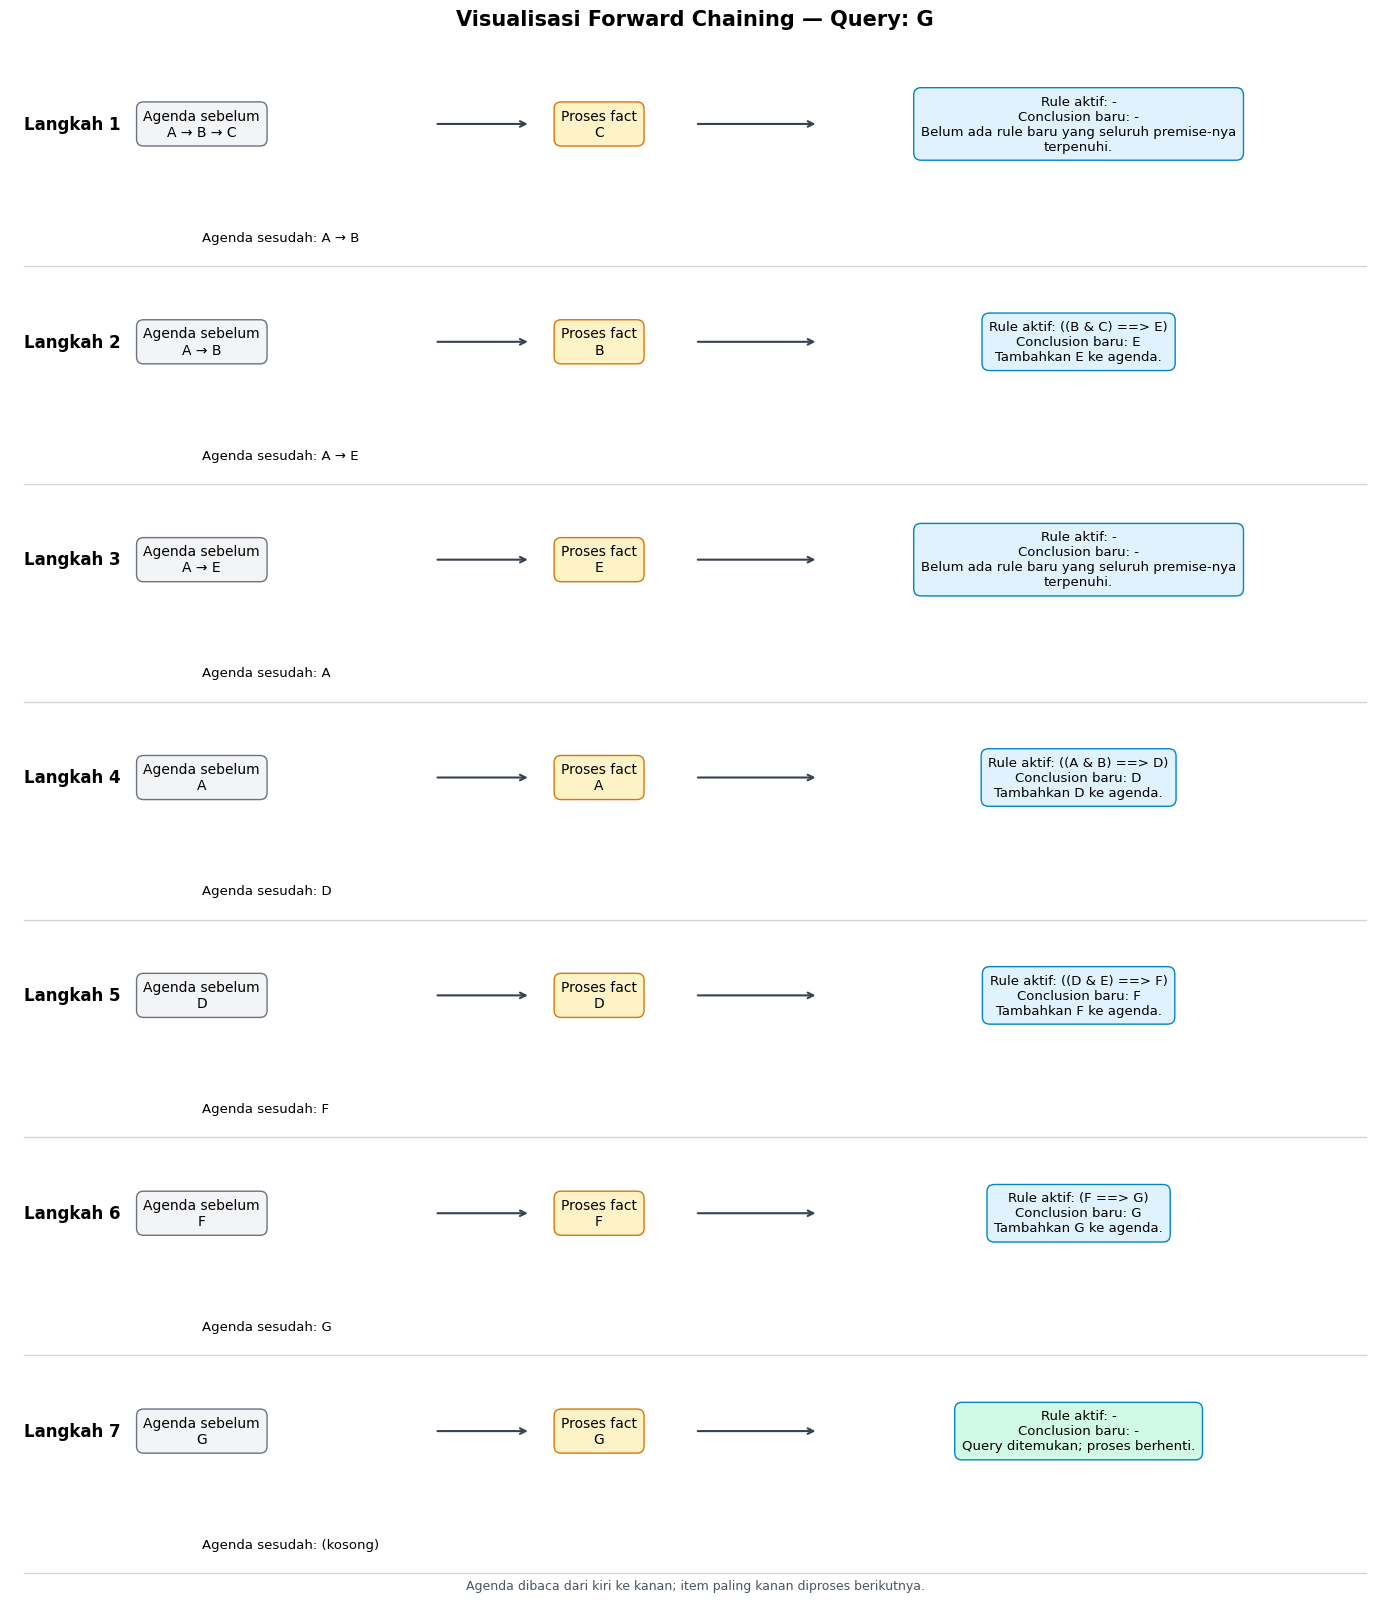

Urutan fact yang diproses: C -> B -> E -> A -> D -> F -> G
Rule penghasil D: (A & B) ==> D  (A dan B menghasilkan D)
Rule penghasil E: (B & C) ==> E  (B dan C menghasilkan E)
Rule penghasil F: (D & E) ==> F  (D dan E menghasilkan F)
Rule penghasil G: F ==> G        (F menghasilkan G)
Kesimpulan: query G berhasil diturunkan dari fact dan rule di KB, jadi KB |= G.


In [16]:
found_fc_exercise, trace_fc_exercise = ask_forward(exercise_kb, "G")

print("G berhasil dibuktikan? (forward):", found_fc_exercise)
display(trace_fc_exercise)
visualize_forward(trace_fc_exercise)

print("Urutan fact yang diproses:", " -> ".join(trace_fc_exercise["fact diproses"]))
print("Rule penghasil D: (A & B) ==> D  (A dan B menghasilkan D)")
print("Rule penghasil E: (B & C) ==> E  (B dan C menghasilkan E)")
print("Rule penghasil F: (D & E) ==> F  (D dan E menghasilkan F)")
print("Rule penghasil G: F ==> G        (F menghasilkan G)")
print("Kesimpulan: query G berhasil diturunkan dari fact dan rule di KB, jadi KB |= G.")

<details>
<summary>Klik untuk melihat pembahasan</summary>

```python
found_fc_exercise, trace_fc_exercise = ask_forward(exercise_kb, "G")

print("G berhasil dibuktikan?", found_fc_exercise)
display(trace_fc_exercise)
visualize_forward(trace_fc_exercise)
```

Hasilnya `True`. Dengan urutan agenda pada fungsi, fact yang diproses adalah:

```text
C → B → E → A → D → F → G
```

Pembuktiannya:

```text
A dan B menghasilkan D
B dan C menghasilkan E
D dan E menghasilkan F
F menghasilkan G
```

Karena query `G` berhasil diturunkan dari fact dan rule di dalam KB, maka
$KB \vDash G$.

</details>


## Soal 3 — Pembuktian dengan Backward Chaining

Gunakan `exercise_kb` dari Soal 1 dan query yang sama, yaitu `G`. Jalankan
backward chaining dengan fungsi yang sudah dibuat setelah Setup:

```python
found_bc_exercise, trace_bc_exercise = ask_backward(exercise_kb, "G")
```

Kerjakan langkah berikut:

1. tampilkan nilai `found_bc_exercise`;
2. tampilkan tabel `trace_bc_exercise`;
3. tampilkan proof-search tree dengan
   `visualize_backward(trace_bc_exercise)`;
4. tentukan root, subgoal, dan leaf fact pada tree;
5. jelaskan pembuktian dari query `G` sampai mencapai fact `A`, `B`, dan `C`;
6. simpulkan apakah `KB \vDash G`.


G berhasil dibuktikan? (backward): True


,langkah,parent,depth,goal,rule diperiksa,rule berhasil,keputusan,hasil
0,1,-,0,G,(F ==> G),(F ==> G),Semua premise pada rule berhasil dibuktikan.,True
1,2,1,1,F,((D & E) ==> F),((D & E) ==> F),Semua premise pada rule berhasil dibuktikan.,True
2,3,2,2,D,((A & B) ==> D),((A & B) ==> D),Semua premise pada rule berhasil dibuktikan.,True
3,4,3,3,A,-,-,Goal sudah tersedia sebagai fact.,True
4,5,3,3,B,-,-,Goal sudah tersedia sebagai fact.,True
5,6,2,2,E,((B & C) ==> E),((B & C) ==> E),Semua premise pada rule berhasil dibuktikan.,True
6,7,6,3,B,-,-,Goal sudah tersedia sebagai fact.,True
7,8,6,3,C,-,-,Goal sudah tersedia sebagai fact.,True


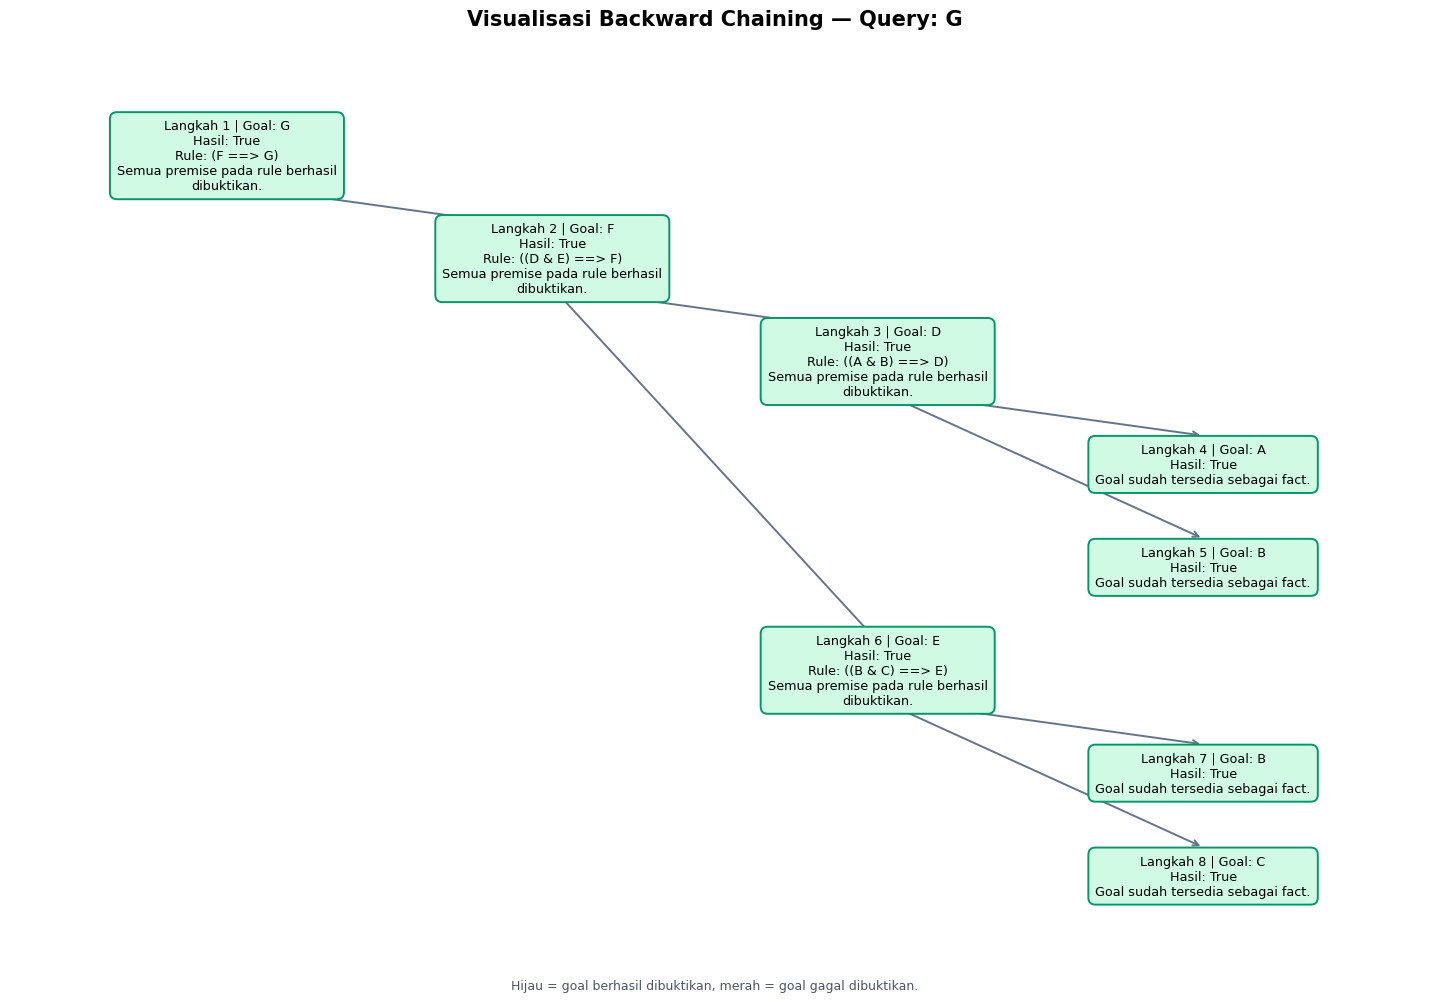

Root      : G
Subgoal   : F, D, E
Leaf fact : A, B, C
Alur: G membutuhkan F; F membutuhkan D dan E;
      D dibuktikan oleh fact A dan B; E dibuktikan oleh fact B dan C.
Kesimpulan: seluruh leaf tersedia sebagai fact sehingga F lalu G terbukti, jadi KB |= G.


In [17]:
found_bc_exercise, trace_bc_exercise = ask_backward(exercise_kb, "G")

print("G berhasil dibuktikan? (backward):", found_bc_exercise)
display(trace_bc_exercise)
visualize_backward(trace_bc_exercise)

print("Root      : G")
print("Subgoal   : F, D, E")
print("Leaf fact : A, B, C")
print("Alur: G membutuhkan F; F membutuhkan D dan E;")
print("      D dibuktikan oleh fact A dan B; E dibuktikan oleh fact B dan C.")
print("Kesimpulan: seluruh leaf tersedia sebagai fact sehingga F lalu G terbukti, jadi KB |= G.")

<details>
<summary>Klik untuk melihat pembahasan</summary>

```python
found_bc_exercise, trace_bc_exercise = ask_backward(exercise_kb, "G")

print("G berhasil dibuktikan?", found_bc_exercise)
display(trace_bc_exercise)
visualize_backward(trace_bc_exercise)
```

Hasilnya `True`. Backward chaining memulai pencarian dari query `G`:

```text
G
└── membutuhkan F
    ├── membutuhkan D
    │   ├── A adalah fact
    │   └── B adalah fact
    └── membutuhkan E
        ├── B adalah fact
        └── C adalah fact
```

- **root** pada tree adalah `G`;
- **subgoal** adalah `F`, `D`, dan `E`;
- **leaf fact** adalah `A`, `B`, dan `C`.

Karena seluruh leaf yang diperlukan tersedia sebagai fact, `D` dan `E`
berhasil dibuktikan. Keduanya membuktikan `F`, lalu `F` membuktikan `G`.
Dengan demikian, $KB \vDash G$.

</details>
